# The Generalization Gap

This notebook visualises the gap between training and test error as a function of the training-set size and of model complexity, using a decision tree on the breast cancer dataset.

## Import Required Libraries

Import numpy, matplotlib and the scikit-learn tools.

In [1]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## Load and Split the Data

Load the breast cancer dataset and hold out a test set for the complexity sweep.

In [2]:
# Load the breast cancer dataset and split it.
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (398, 30), Test: (171, 30)


## Error vs Training-Set Size

A learning curve records training and validation error as more instances become available.

In [3]:
# Compute a learning curve over increasing training sizes.
sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=4, random_state=42),
    X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42)

# Convert accuracy scores into error rates.
train_err = 1 - train_scores.mean(axis=1)
val_err = 1 - val_scores.mean(axis=1)

## Plotting the Learning Curve

As the training set grows, the two error curves converge and the gap shrinks.

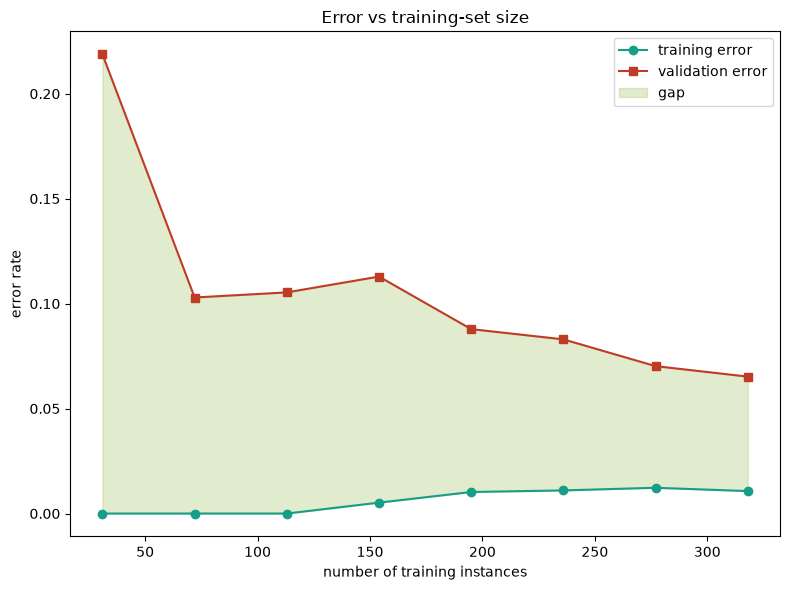

In [4]:
# Plot training and validation error against training size.
plt.figure(figsize=(8, 6))
plt.plot(sizes, train_err, marker="o", color=colors[0],
         label="training error")
plt.plot(sizes, val_err, marker="s", color=colors[3],
         label="validation error")
plt.fill_between(sizes, train_err, val_err, color=colors[2],
                 alpha=0.3, label="gap")
plt.title("Error vs training-set size")
plt.xlabel("number of training instances")
plt.ylabel("error rate")
plt.legend()
plt.tight_layout()
plt.show()

## Error vs Model Complexity

Sweeping the tree depth increases capacity; deeper trees fit the training data ever better.

In [5]:
# Sweep the tree depth and record train and test error.
depths = range(1, 16)
train_err_d, test_err_d = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_err_d.append(1 - tree.score(X_train, y_train))
    test_err_d.append(1 - tree.score(X_test, y_test))

best_depth = list(depths)[int(np.argmin(test_err_d))]
print(f"Depth with lowest test error: {best_depth}")

Depth with lowest test error: 5


## Plotting the Complexity Curve

The training error keeps falling while the test error bottoms out and then rises: the widening gap is overfitting.

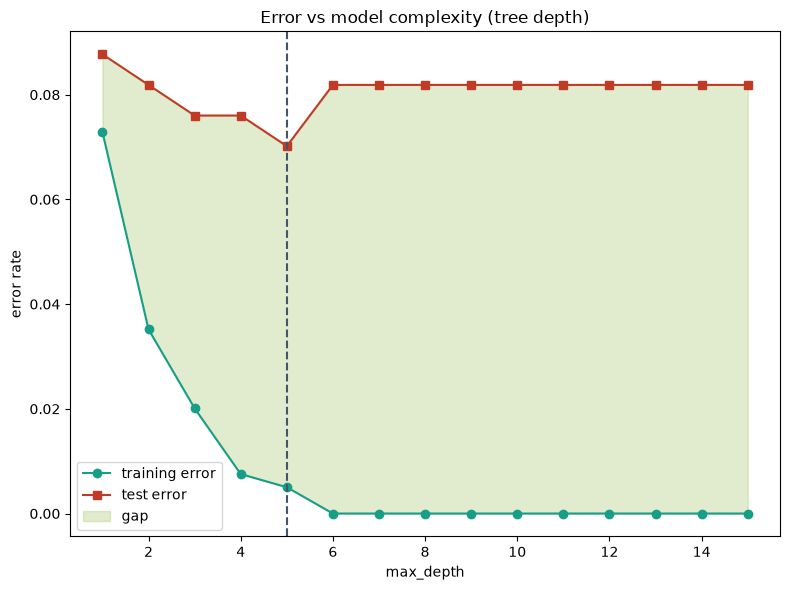

In [6]:
# Plot train and test error against tree depth.
plt.figure(figsize=(8, 6))
plt.plot(list(depths), train_err_d, marker="o", color=colors[0],
         label="training error")
plt.plot(list(depths), test_err_d, marker="s", color=colors[3],
         label="test error")
plt.fill_between(list(depths), train_err_d, test_err_d,
                 color=colors[2], alpha=0.3, label="gap")
plt.axvline(best_depth, color=colors[4], linestyle="--")
plt.title("Error vs model complexity (tree depth)")
plt.xlabel("max_depth")
plt.ylabel("error rate")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- **Generalization gap**: the distance between training and test error.
- **More data**: shrinks the gap as the curves converge.
- **More complexity**: lowers training error but eventually raises test error.
- **Optimum**: the depth that minimises test error balances the two effects.